<a href="https://colab.research.google.com/github/AnkitSingh946/AI-image-detector/blob/main/CNN_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install torch torchvision streamlit pillow matplotlib seaborn scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 122.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()  # Upload your kaggle.json here when prompted

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "project",\r\n  "key": "KGAT_d0e7bf95551fa15bf39765ad99447381"\r\n}'}

In [ ]:
import os

# Move kaggle.json to correct location
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download CIFAKE dataset
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip -d cifake
print("✅ Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
cifake-real-and-ai-generated-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace cifake/test/FAKE/0 (10).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ Dataset downloaded!


In [ ]:
import os

# Check folder structure
for split in ['train', 'test']:
    for label in ['REAL', 'FAKE']:
        path = f'cifake/{split}/{label}'
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} images")

train/REAL: 50000 images
train/FAKE: 50000 images
test/REAL: 10000 images
test/FAKE: 10000 images


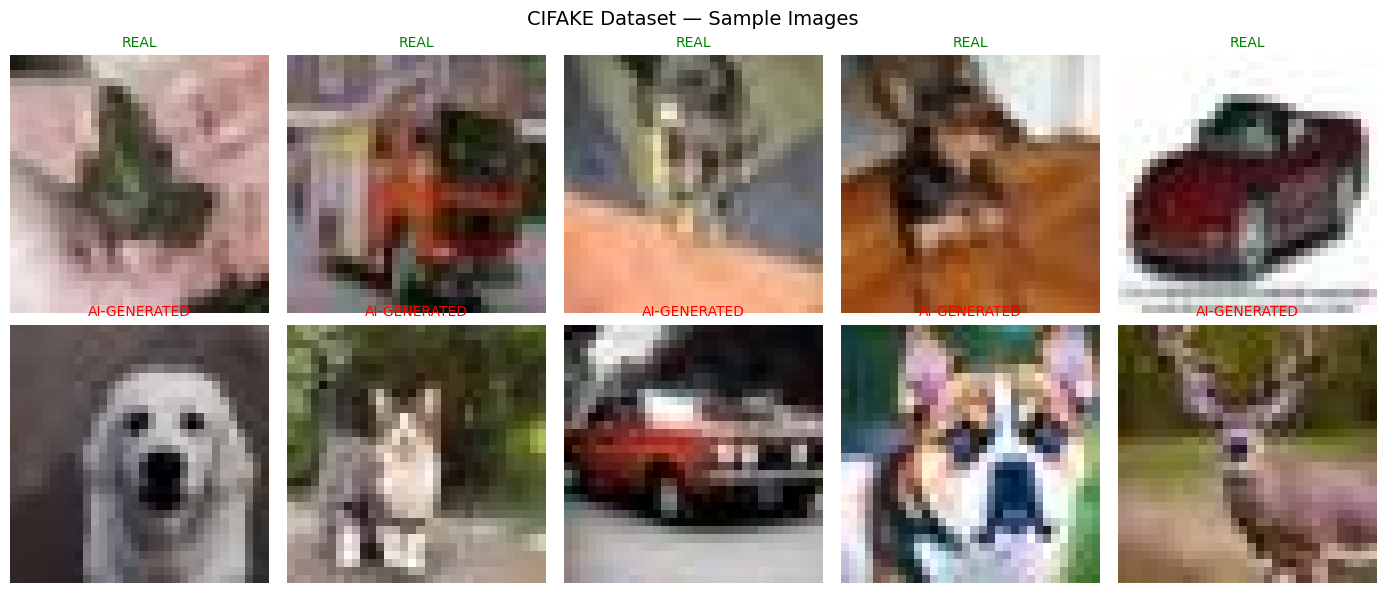

✅ Sample images visualised!


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random, os

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAKE Dataset — Sample Images', fontsize=14)

for col in range(5):
    # Real image
    real_path = 'cifake/train/REAL'
    img_name  = random.choice(os.listdir(real_path))
    img = Image.open(f'{real_path}/{img_name}')
    axes[0, col].imshow(img)
    axes[0, col].set_title('REAL', color='green', fontsize=10)
    axes[0, col].axis('off')

    # AI-generated image
    fake_path = 'cifake/train/FAKE'
    img_name  = random.choice(os.listdir(fake_path))
    img = Image.open(f'{fake_path}/{img_name}')
    axes[1, col].imshow(img)
    axes[1, col].set_title('AI-GENERATED', color='red', fontsize=10)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("✅ Sample images visualised!")

In [ ]:
import torch
import torchvision

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
print("✅ All good — Day 1 complete!")

PyTorch version : 2.10.0+cu128
Torchvision     : 0.25.0+cu128
GPU available   : True
GPU name        : Tesla T4
✅ All good — Day 1 complete!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [ ]:
# Image size ResNet expects
IMG_SIZE   = 224
BATCH_SIZE = 64

# Transforms — training gets augmentation, val/test just resize
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225])    # ImageNet std
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder('cifake/train', transform=train_transform)
test_dataset  = datasets.ImageFolder('cifake/test',  transform=test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Check class mapping
print(f"Classes : {train_dataset.classes}")   # ['FAKE', 'REAL']
print(f"Train   : {len(train_dataset)} images")
print(f"Test    : {len(test_dataset)}  images")
print("✅ Data loaded!")

Classes : ['FAKE', 'REAL']
Train   : 100000 images
Test    : 20000  images
✅ Data loaded!


In [ ]:
# Load pretrained ResNet-18
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer for binary classification (REAL vs FAKE)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)          # 2 classes: FAKE, REAL
)

model = model.to(device)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready — Trainable parameters: {trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 90.3MB/s]


✅ Model ready — Trainable parameters: 131,842


In [ ]:
EPOCHS    = 8
LR        = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LR)

# Reduce LR if validation loss stops improving
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print(f"✅ Training setup done — {EPOCHS} epochs, LR={LR}")

✅ Training setup done — 8 epochs, LR=0.001


In [ ]:
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

best_val_acc = 0.0

for epoch in range(EPOCHS):
    # ── Training phase ──────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ── Validation phase ─────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / len(test_loader)
    val_acc  = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        saved = "💾 saved"
    else:
        saved = ""

    print(f"Epoch [{epoch+1}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%  {saved}")

print(f"\n✅ Training complete! Best Val Accuracy: {best_val_acc:.2f}%")

Epoch [1/8]  Train Loss: 0.3674  Train Acc: 83.50%  |  Val Loss: 0.3499  Val Acc: 84.48%  💾 saved
Epoch [2/8]  Train Loss: 0.3184  Train Acc: 86.30%  |  Val Loss: 0.3516  Val Acc: 84.51%  💾 saved
Epoch [3/8]  Train Loss: 0.3016  Train Acc: 87.24%  |  Val Loss: 0.3133  Val Acc: 86.58%  💾 saved
Epoch [4/8]  Train Loss: 0.2803  Train Acc: 88.26%  |  Val Loss: 0.2819  Val Acc: 87.97%  💾 saved
Epoch [5/8]  Train Loss: 0.2756  Train Acc: 88.57%  |  Val Loss: 0.2685  Val Acc: 88.53%  💾 saved
Epoch [6/8]  Train Loss: 0.2665  Train Acc: 88.98%  |  Val Loss: 0.2966  Val Acc: 87.46%  
Epoch [7/8]  Train Loss: 0.2583  Train Acc: 89.34%  |  Val Loss: 0.2573  Val Acc: 89.35%  💾 saved
Epoch [8/8]  Train Loss: 0.2588  Train Acc: 89.43%  |  Val Loss: 0.2679  Val Acc: 88.89%  

✅ Training complete! Best Val Accuracy: 89.35%


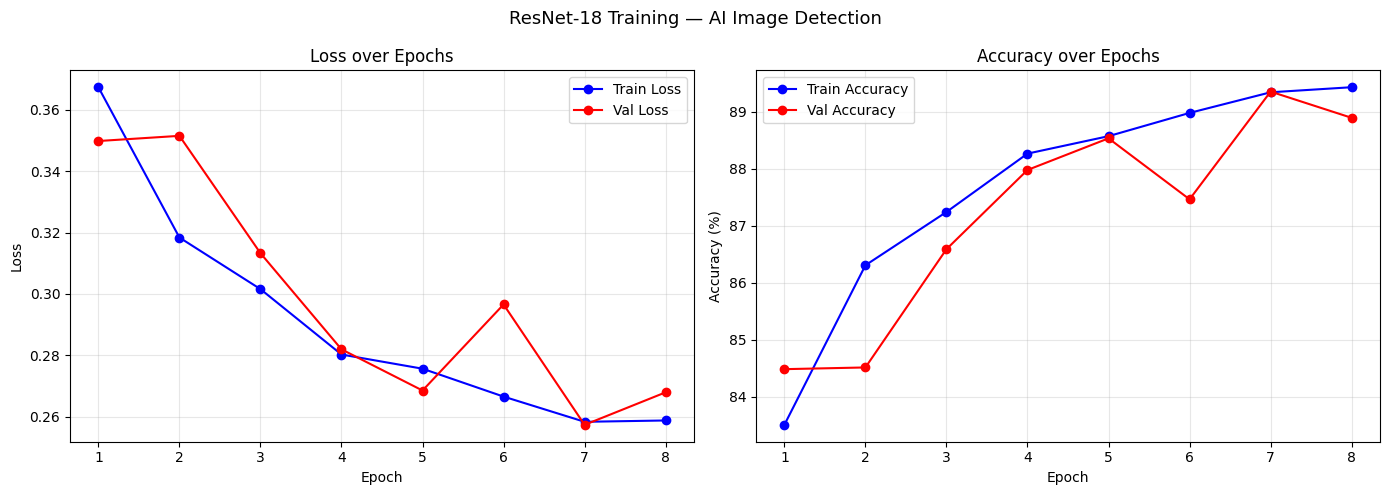

✅ Training curves saved as training_curves.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss plot
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs_range, val_losses,   'r-o', label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, train_accs, 'b-o', label='Train Accuracy')
ax2.plot(epochs_range, val_accs,   'r-o', label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet-18 Training — AI Image Detection', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("✅ Training curves saved as training_curves.png")

In [ ]:
# Save model + class info together for easy loading later
torch.save({
    'model_state_dict' : model.state_dict(),
    'class_names'      : train_dataset.classes,
    'val_accuracy'     : best_val_acc,
}, 'ai_detector.pth')

print("✅ Model saved as ai_detector.pth")
print(f"   Classes : {train_dataset.classes}")
print(f"   Best accuracy : {best_val_acc:.2f}%")

✅ Model saved as ai_detector.pth
   Classes : ['FAKE', 'REAL']
   Best accuracy : 89.35%


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild model architecture
model = models.resnet18(weights=None)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

# Load saved weights
checkpoint = torch.load('ai_detector.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
class_names = checkpoint['class_names']   # ['FAKE', 'REAL']
model = model.to(device)
model.eval()

print(f"✅ Model loaded!")
print(f"   Classes     : {class_names}")
print(f"   Best Val Acc: {checkpoint['val_accuracy']:.2f}%")

✅ Model loaded!
   Classes     : ['FAKE', 'REAL']
   Best Val Acc: 89.35%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Test transform (same as Day 2)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder('cifake/test', transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
accuracy = 100 * (all_preds == all_labels).sum() / len(all_labels)
print(f"✅ Test Accuracy: {accuracy:.2f}%")

✅ Test Accuracy: 88.89%


In [ ]:
print("\n📊 Classification Report:")
print("=" * 50)
report = classification_report(all_labels, all_preds,
                                target_names=class_names)
print(report)


📊 Classification Report:
              precision    recall  f1-score   support

        FAKE       0.85      0.94      0.89     10000
        REAL       0.94      0.84      0.88     10000

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



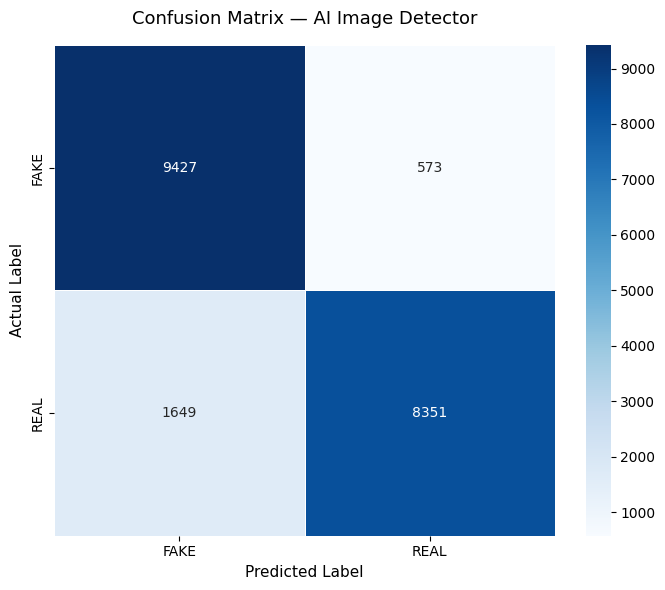


📋 Breakdown:
   True Positives  (AI correctly detected)   : 8,351
   True Negatives  (Real correctly detected)  : 9,427
   False Positives (Real wrongly called AI)   : 573
   False Negatives (AI wrongly called Real)   : 1,649
✅ Confusion matrix saved!


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)

plt.title('Confusion Matrix — AI Image Detector', fontsize=13, pad=15)
plt.ylabel('Actual Label',    fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Print breakdown clearly
tn, fp, fn, tp = cm.ravel()
print(f"\n📋 Breakdown:")
print(f"   True Positives  (AI correctly detected)   : {tp:,}")
print(f"   True Negatives  (Real correctly detected)  : {tn:,}")
print(f"   False Positives (Real wrongly called AI)   : {fp:,}")
print(f"   False Negatives (AI wrongly called Real)   : {fn:,}")
print("✅ Confusion matrix saved!")

/tmp/ipykernel_596/3230601865.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_596/3230601865.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_596/3230601865.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('predictions_grid.png', dpi=150)
/tmp/ipykernel_596/3230601865.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('predictions_grid.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

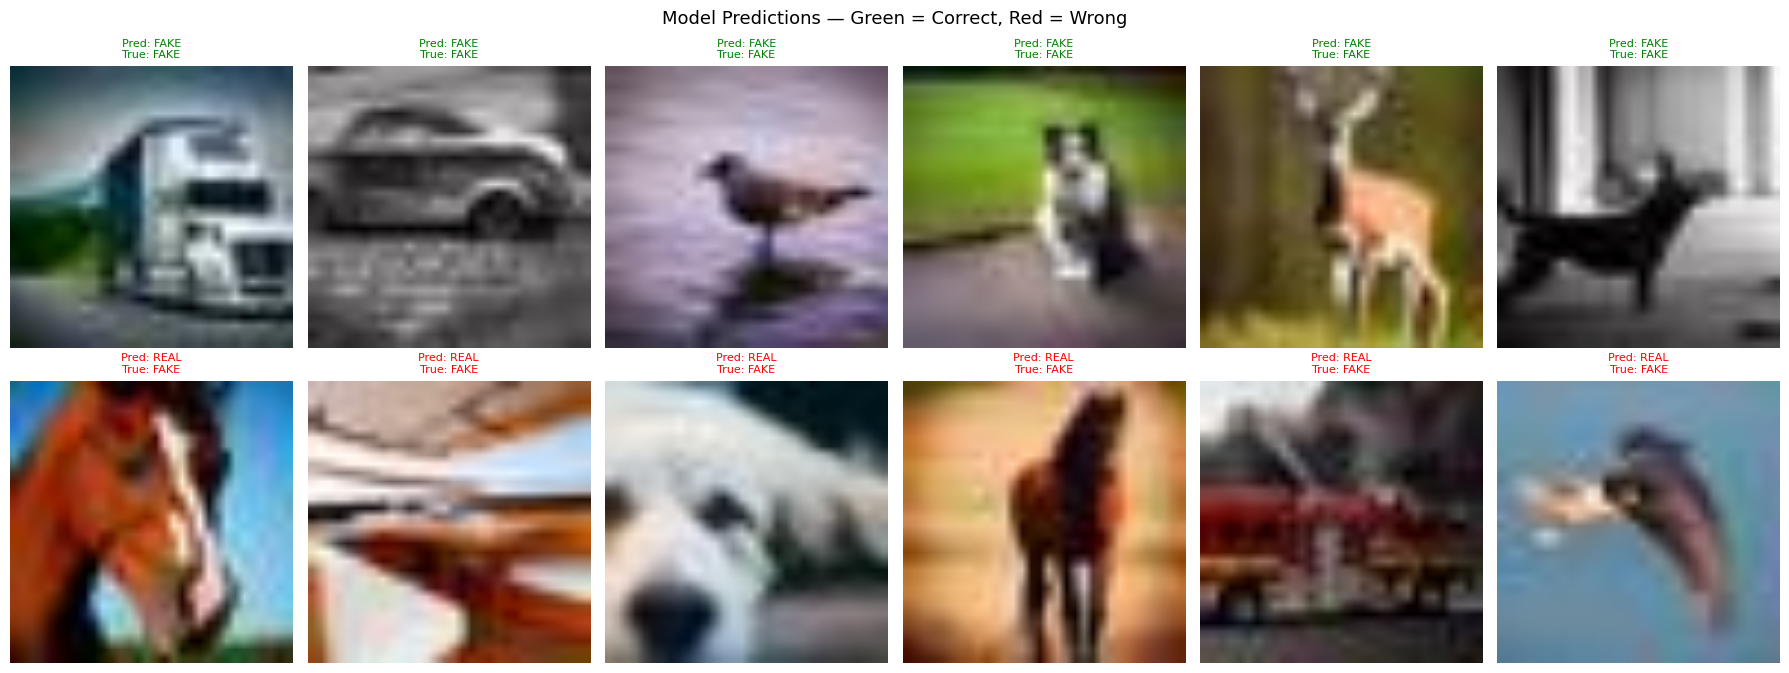

✅ Predictions grid saved!


In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Model Predictions — Green = Correct, Red = Wrong', fontsize=13)

# Collect some correct and wrong predictions
correct_idxs = np.where(all_preds == all_labels)[0]
wrong_idxs   = np.where(all_preds != all_labels)[0]

def show_sample(ax, dataset, idx, pred, label, class_names):
    img, _ = dataset[idx]
    # Denormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    img  = img * std[:, None, None] + mean[:, None, None]
    img  = img.permute(1, 2, 0).numpy()
    img  = np.clip(img, 0, 1)

    ax.imshow(img)
    color = 'green' if pred == label else 'red'
    ax.set_title(f"Pred: {class_names[pred]}\nTrue: {class_names[label]}",
                 fontsize=8, color=color)
    ax.axis('off')

# Top row: correct predictions
for col in range(6):
    idx = correct_idxs[col]
    show_sample(axes[0, col], test_dataset, idx,
                all_preds[idx], all_labels[idx], class_names)
axes[0, 0].set_ylabel('Correct ✅', fontsize=10, color='green')

# Bottom row: wrong predictions
for col in range(6):
    idx = wrong_idxs[col]
    show_sample(axes[1, col], test_dataset, idx,
                all_preds[idx], all_labels[idx], class_names)
axes[1, 0].set_ylabel('Wrong ❌', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('predictions_grid.png', dpi=150)
plt.show()
print("✅ Predictions grid saved!")

Saving real cat.webp to real cat (1).webp

Testing: real cat (1).webp


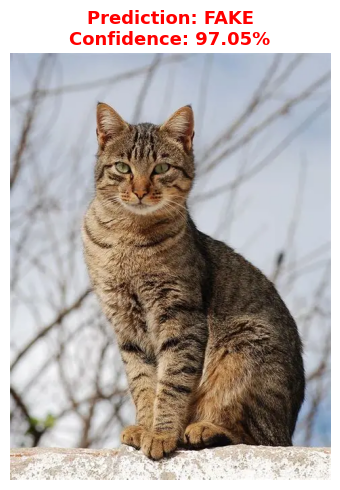


🔍 Result: FAKE
   Confidence : 97.05%
   FAKE prob  : 97.05%
   REAL prob  : 2.95%


In [ ]:
def predict_image(image_path):
    """Predict if a single image is REAL or AI-generated."""

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    # Load and transform image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs  = torch.softmax(output, dim=1)[0]
        pred   = torch.argmax(probs).item()

    label      = class_names[pred]
    confidence = probs[pred].item() * 100

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    color = 'red' if label == 'FAKE' else 'green'
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%",
              fontsize=13, color=color, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n🔍 Result: {label}")
    print(f"   Confidence : {confidence:.2f}%")
    print(f"   FAKE prob  : {probs[0].item()*100:.2f}%")
    print(f"   REAL prob  : {probs[1].item()*100:.2f}%")

    return label, confidence

# Upload your own image and test!
from google.colab import files
uploaded = files.upload()   # Upload any image (DALL-E, real photo, etc.)

for filename in uploaded.keys():
    print(f"\nTesting: {filename}")
    predict_image(filename)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='weighted') * 100
recall    = recall_score(all_labels, all_preds, average='weighted')    * 100
f1        = f1_score(all_labels, all_preds, average='weighted')        * 100

print("=" * 45)
print("      📊 FINAL MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"  Accuracy   : {accuracy:.2f}%")
print(f"  Precision  : {precision:.2f}%")
print(f"  Recall     : {recall:.2f}%")
print(f"  F1-Score   : {f1:.2f}%")
print("=" * 45)
print("  Model      : ResNet-18 (fine-tuned)")
print("  Dataset    : CIFAKE (20,000 test images)")
print("  Classes    : REAL vs AI-Generated")
print("=" * 45)

      📊 FINAL MODEL EVALUATION SUMMARY
  Accuracy   : 88.89%
  Precision  : 89.35%
  Recall     : 88.89%
  F1-Score   : 88.86%
  Model      : ResNet-18 (fine-tuned)
  Dataset    : CIFAKE (20,000 test images)
  Classes    : REAL vs AI-Generated


In [ ]:
from google.colab import files

# Only run this if ai_detector.pth is NOT already in your file list
uploaded = files.upload()   # upload ai_detector.pth from your computer
print("✅ Model uploaded!")

Saving ai_detector.pth to ai_detector (1).pth
✅ Model uploaded!


In [ ]:
torch.save(model.state_dict(), 'ai_detector.pth')

In [ ]:
from google.colab import files
files.download('ai_detector.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>